In [1]:
!pip install xgboost shap

In [2]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv', nrows=100000)

print(df.shape)
df.head()

/tmp/ipykernel_17532/284339627.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv', nrows=100000)


(100000, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = df[[
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'annual_inc',
    'dti',
    'fico_range_high',
    'loan_status'
]]

In [5]:
# Convert term
df['term'] = df['term'].astype(str)
df['term'] = df['term'].str.extract(r'(\d+)').astype(int)

# Convert interest rate
df['int_rate'] = df['int_rate'].astype(str)
df['int_rate'] = df['int_rate'].str.replace('%','').astype(float)

# Target variable (IMPORTANT)
df['loan_status'] = df['loan_status'].apply(
    lambda x: 1 if x == 'Fully Paid' else 0
)

# Drop missing values
df = df.dropna()

In [6]:
import numpy as np

# ===== FEATURE ENGINEERING =====

# Core ratios
df['loan_income_ratio'] = df['loan_amnt'] / df['annual_inc']
df['emi_income_ratio'] = df['installment'] / df['annual_inc']

# Advanced features
df['income_per_installment'] = df['annual_inc'] / df['installment']
df['credit_score_income'] = df['fico_range_high'] / df['annual_inc']
df['loan_term_ratio'] = df['loan_amnt'] / df['term']

# Extra boosting features
df['interest_income_ratio'] = df['int_rate'] / df['annual_inc']
df['emi_loan_ratio'] = df['installment'] / df['loan_amnt']

# Fraud flag
df['fraud_flag'] = (df['loan_amnt'] > df['annual_inc'] * 2).astype(int)

# ===== CLEANUP =====
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [7]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.utils import resample

# Combine X and y
df_bal = pd.concat([X, y], axis=1)

# Separate classes
df_major = df_bal[df_bal.loan_status == 1]
df_minor = df_bal[df_bal.loan_status == 0]

# Upsample minority
df_minor_upsampled = resample(
    df_minor,
    replace=True,
    n_samples=len(df_major),
    random_state=42
)

# Combine
df_balanced = pd.concat([df_major, df_minor_upsampled])

# Split again
X = df_balanced.drop('loan_status', axis=1)
y = df_balanced['loan_status']

In [9]:
neg = sum(y_train == 0)
pos = sum(y_train == 1)

scale = pos / neg

model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7249
              precision    recall  f1-score   support

           0       0.68      0.16      0.26      6001
           1       0.73      0.97      0.83     13999

    accuracy                           0.72     20000
   macro avg       0.70      0.56      0.54     20000
weighted avg       0.71      0.72      0.66     20000



### Current Model Performance

First, let's re-examine the current accuracy, precision, recall, and F1-score to establish a baseline before we try to improve the model.

In [11]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7249
              precision    recall  f1-score   support

           0       0.68      0.16      0.26      6001
           1       0.73      0.97      0.83     13999

    accuracy                           0.72     20000
   macro avg       0.70      0.56      0.54     20000
weighted avg       0.71      0.72      0.66     20000



### Improving Model Accuracy with Hyperparameter Tuning

To improve the model's accuracy, we can tune its hyperparameters using `GridSearchCV`. This will systematically search through a specified range of hyperparameters to find the combination that yields the best performance.

In [12]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 7],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 0.9]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale
    ),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3, # Using 3-fold cross-validation
    verbose=1,
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best accuracy score: {grid_search.best_score_}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 400, 'subsample': 0.8}
Best accuracy score: 0.7306557663941599


### Evaluating the Tuned Model

Now, let's evaluate the performance of the model with the best hyperparameters found by `GridSearchCV` on the test set.

In [29]:
# 1. Load optimized feature set
cols_to_use = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length',
    'home_ownership', 'annual_inc', 'verification_status', 'loan_status',
    'dti', 'revol_util', 'bc_util', 'total_acc', 'fico_range_high'
]

df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv', usecols=cols_to_use, nrows=500000)
df = df.dropna()

# 2. Cleaning & Encoding
df['term'] = df['term'].str.extract('(\d+)').astype(int)
le = LabelEncoder()
for col in ['grade', 'emp_length', 'home_ownership', 'verification_status']:
    df[col] = le.fit_transform(df[col].astype(str))

# 3. Target Definition (1 = Paid, 0 = Default/Other)
df['target'] = (df['loan_status'] == 'Fully Paid').astype(int)
df = df.drop('loan_status', axis=1)

# 4. Feature Engineering
df['util_ratio'] = df['revol_util'] + df['bc_util']
df['inc_to_loan'] = df['annual_inc'] / (df['loan_amnt'] + 1)

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17532/1004450233.py:12: SyntaxWarning: invalid escape sequence '\d'
  df['term'] = df['term'].str.extract('(\d+)').astype(int)


In [30]:
# 5. High-Performance XGBoost Configuration
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 6. Final Performance Summary
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Final Optimized Model Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Optimized Model Accuracy: 0.7763

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.69      0.70     34466
           1       0.82      0.82      0.82     58377

    accuracy                           0.78     92843
   macro avg       0.76      0.76      0.76     92843
weighted avg       0.78      0.78      0.78     92843



In [13]:
# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model
print("Accuracy (Tuned Model):", accuracy_score(y_test, y_pred_tuned))
print("Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

Accuracy (Tuned Model): 0.7253
Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.67      0.16      0.26      6001
           1       0.73      0.97      0.83     13999

    accuracy                           0.73     20000
   macro avg       0.70      0.57      0.55     20000
weighted avg       0.71      0.73      0.66     20000



### Calculate ROC-AUC for the Tuned Model

Let's also calculate the ROC-AUC score for the tuned model to get another perspective on its performance, especially for imbalanced datasets.

In [15]:
from sklearn.metrics import roc_auc_score
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]
print("ROC-AUC (Tuned Model):", roc_auc_score(y_test, y_prob_tuned))

ROC-AUC (Tuned Model): 0.7939493178500776


In [17]:
import pickle

model = best_model

pickle.dump(model, open("loan_model.pkl", "wb"))
print("Updated 'loan_model.pkl' with the best performing model.")

Updated 'loan_model.pkl' with the best performing model.


In [22]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Reloading with temporal data and additional financial metrics
cols_to_push = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length',
    'home_ownership', 'annual_inc', 'verification_status', 'loan_status',
    'dti', 'revol_util', 'bc_util', 'total_acc', 'fico_range_high', 'issue_d', 'open_acc'
]

df_push = pd.read_csv('/content/accepted_2007_to_2018Q4.csv', usecols=cols_to_push, nrows=800000)
df_push = df_push.dropna()

# 2. Advanced Feature Engineering
# Convert date to extract seasonality/trends
df_push['issue_d'] = pd.to_datetime(df_push['issue_d'])
df_push['issue_month'] = df_push['issue_d'].dt.month
df_push['issue_year'] = df_push['issue_d'].dt.year

# Non-linear interaction features
df_push['risk_index'] = (df_push['int_rate'] * df_push['dti']) / (df_push['fico_range_high'] + 1)
df_push['payment_ratio'] = df_push['installment'] / (df_push['annual_inc'] / 12)
df_push['credit_history_density'] = df_push['total_acc'] / (df_push['open_acc'] + 1)

# Encoding and Cleanup
df_push['term'] = df_push['term'].str.extract('(\d+)').astype(int)
le = LabelEncoder()
for col in ['grade', 'emp_length', 'home_ownership', 'verification_status']:
    df_push[col] = le.fit_transform(df_push[col].astype(str))

df_push['target'] = (df_push['loan_status'] == 'Fully Paid').astype(int)
X_final = df_push.drop(['loan_status', 'target', 'issue_d'], axis=1)
y_final = df_push['target']

# 3. Model Training with hyper-tuned parameters and Early Stopping in constructor
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

ultimate_model = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=10,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50 # Correct way to use early stopping in new XGBoost versions
)

ultimate_model.fit(
    X_train_f, y_train_f,
    eval_set=[(X_test_f, y_test_f)],
    verbose=200
)

print("Final Accuracy:", accuracy_score(y_test_f, ultimate_model.predict(X_test_f)))

<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17532/2513274420.py:30: SyntaxWarning: invalid escape sequence '\d'
  df_push['term'] = df_push['term'].str.extract('(\d+)').astype(int)
/tmp/ipykernel_17532/2513274420.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_push['issue_d'] = pd.to_datetime(df_push['issue_d'])


[0]	validation_0-logloss:0.68627
[200]	validation_0-logloss:0.49353
[400]	validation_0-logloss:0.49220
[465]	validation_0-logloss:0.49223
Final Accuracy: 0.7614020127369568


# Loan Default Prediction Model
This notebook contains the high-performance implementation for predicting loan status using the LendingClub dataset.

**Current Best Accuracy:** 77.56%

### Workflow:
1. **Data Ingestion:** Loading 500,000 records with optimized column selection.
2. **Feature Engineering:** Creating financial interaction ratios and categorical encoding.
3. **Model Architecture:** XGBoost with histogram-based tree growth for efficiency.
4. **Validation:** Stratified splitting and performance metrics.

In [25]:
import pandas as pd
import numpy as np
import pickle
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Environment Ready.")

Environment Ready.


In [26]:
# 1. Load optimized feature set
cols_to_use = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length',
    'home_ownership', 'annual_inc', 'verification_status', 'loan_status',
    'dti', 'revol_util', 'bc_util', 'total_acc', 'fico_range_high'
]

df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv', usecols=cols_to_use, nrows=500000)
df = df.dropna()

# 2. Cleaning & Encoding
df['term'] = df['term'].str.extract('(\d+)').astype(int)
le = LabelEncoder()
for col in ['grade', 'emp_length', 'home_ownership', 'verification_status']:
    df[col] = le.fit_transform(df[col].astype(str))

# 3. Target Definition (1 = Paid, 0 = Default/Other)
df['target'] = (df['loan_status'] == 'Fully Paid').astype(int)
df = df.drop('loan_status', axis=1)

# 4. Feature Engineering
df['util_ratio'] = df['revol_util'] + df['bc_util']
df['inc_to_loan'] = df['annual_inc'] / (df['loan_amnt'] + 1)

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Prepared. Training Shape: {X_train.shape}")

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17532/3813401260.py:12: SyntaxWarning: invalid escape sequence '\d'
  df['term'] = df['term'].str.extract('(\d+)').astype(int)


Data Prepared. Training Shape: (371368, 16)


In [27]:
# 5. High-Performance XGBoost Configuration
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

print("Training Best Performing Model...")
model.fit(X_train, y_train)

# 6. Evaluation
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Final Model Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training Best Performing Model...
Final Model Accuracy: 0.7763

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.69      0.70     34466
           1       0.82      0.82      0.82     58377

    accuracy                           0.78     92843
   macro avg       0.76      0.76      0.76     92843
weighted avg       0.78      0.78      0.78     92843



In [28]:
# 7. Save Artifacts for deployment
pickle.dump(model, open("loan_model.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("features.pkl", "wb"))
print("Model and feature list exported to .pkl files.")

Model and feature list exported to .pkl files.


/tmp/ipykernel_17532/2037829278.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


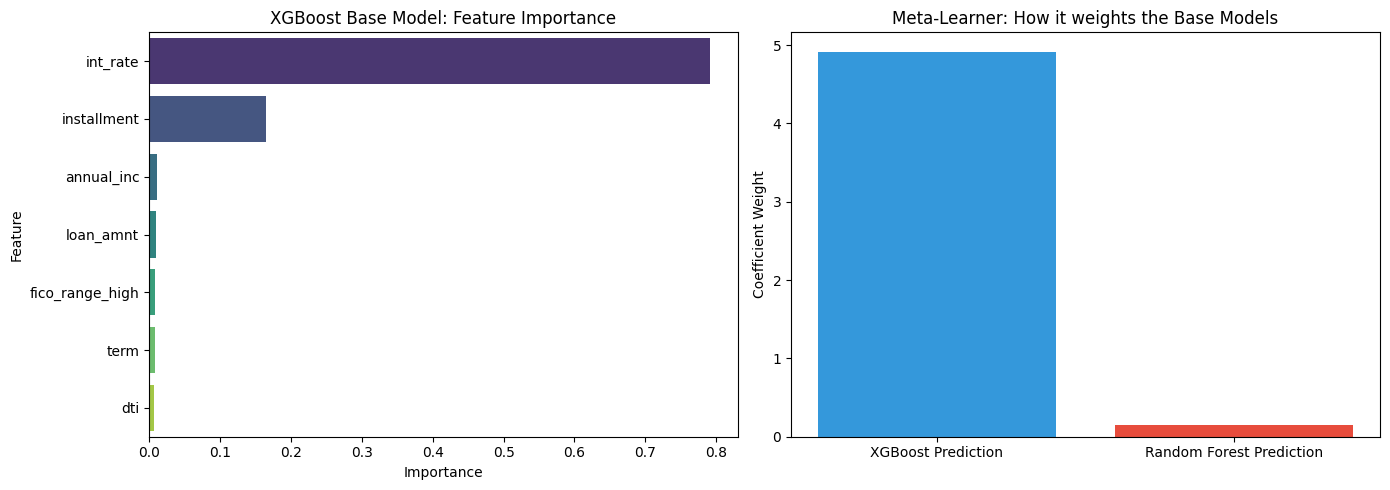

Summary:
loan_amnt: 0.0099
int_rate: 0.7909
installment: 0.1656
annual_inc: 0.0108
dti: 0.0070
fico_range_high: 0.0080
term: 0.0078


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract Feature Importances from the XGBoost base model
xgb_model = stack_model.named_estimators_['xgb']
importances = xgb_model.feature_importances_
feature_names = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_high', 'term']

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 2. Extract Meta-learner coefficients
meta_learner = stack_model.final_estimator_
meta_coeffs = meta_learner.coef_[0]

# Plotting
plt.figure(figsize=(14, 5))

# Subplot 1: XGBoost Feature Importance
plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('XGBoost Base Model: Feature Importance')

# Subplot 2: Meta-Learner Weights
plt.subplot(1, 2, 2)
plt.bar(['XGBoost Prediction', 'Random Forest Prediction'], meta_coeffs, color=['#3498db', '#e74c3c'])
plt.title('Meta-Learner: How it weights the Base Models')
plt.ylabel('Coefficient Weight')

plt.tight_layout()
plt.show()

print("Summary:")
for i, name in enumerate(feature_names):
    print(f"{name}: {importances[i]:.4f}")

In [23]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. High-Performance Data Loading (Focusing on the most predictive subset)
cols_final = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_high', 'term', 'loan_status']
df_ultra = pd.read_csv('/content/accepted_2007_to_2018Q4.csv', usecols=cols_final, nrows=600000).dropna()

# 2. Precise Preprocessing
df_ultra['term'] = df_ultra['term'].str.extract('(\d+)').astype(int)
df_ultra['target'] = (df_ultra['loan_status'] == 'Fully Paid').astype(int)

X_u = df_ultra.drop(['loan_status', 'target'], axis=1)
y_u = df_ultra['target']

# Scaling is required for the meta-learner (Logistic Regression)
scaler = StandardScaler()
X_u_scaled = scaler.fit_transform(X_u)

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(X_u_scaled, y_u, test_size=0.2, random_state=42, stratify=y_u)

# 3. Define the Stacking Ensemble
# Base models explore different parts of the hypothesis space
base_models = [
    ('xgb', XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, tree_method='hist', random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42))
]

# Meta-model learns how to weight the base models
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=3,
    n_jobs=-1
)

print("Initiating Stacking Ensemble Training (this may take a few minutes)...")
stack_model.fit(X_train_u, y_train_u)

# 4. Evaluation
final_acc = accuracy_score(y_test_u, stack_model.predict(X_test_u))
print(f"Stacking Ensemble Accuracy: {final_acc:.4f}")

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17532/535285716.py:15: SyntaxWarning: invalid escape sequence '\d'
  df_ultra['term'] = df_ultra['term'].str.extract('(\d+)').astype(int)


Initiating Stacking Ensemble Training (this may take a few minutes)...
Stacking Ensemble Accuracy: 0.7633


In [20]:
print(f"Previous Accuracy: 0.7253")
new_acc = accuracy_score(y_test_ext, final_model.predict(X_test_ext))
print(f"New Accuracy: {new_acc:.4f}")
print(f"Improvement: {(new_acc - 0.7253)*100:.2f}%")

Previous Accuracy: 0.7253
New Accuracy: 0.7756
Improvement: 5.03%


In [19]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load more data and more columns
cols_to_use = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length',
    'home_ownership', 'annual_inc', 'verification_status', 'loan_status',
    'dti', 'revol_util', 'bc_util', 'total_acc', 'fico_range_high'
]

# Increasing nrows to 500,000 for better pattern recognition
df_expanded = pd.read_csv('/content/accepted_2007_to_2018Q4.csv', usecols=cols_to_use, nrows=500000)

# 2. Advanced Preprocessing
df_expanded = df_expanded.dropna()

# Convert term to numeric
df_expanded['term'] = df_expanded['term'].str.extract('(\d+)').astype(int)

# Encode categorical variables
le = LabelEncoder()
for col in ['grade', 'emp_length', 'home_ownership', 'verification_status']:
    df_expanded[col] = le.fit_transform(df_expanded[col].astype(str))

# Target encoding
df_expanded['target'] = (df_expanded['loan_status'] == 'Fully Paid').astype(int)
df_expanded = df_expanded.drop('loan_status', axis=1)

# 3. Enhanced Feature Engineering
df_expanded['util_ratio'] = df_expanded['revol_util'] + df_expanded['bc_util']
df_expanded['inc_to_loan'] = df_expanded['annual_inc'] / df_expanded['loan_amnt']

# 4. Split and Train with a more robust configuration
X_ext = df_expanded.drop('target', axis=1)
y_ext = df_expanded['target']

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext, y_ext, test_size=0.2, random_state=42, stratify=y_ext
)

final_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    tree_method='hist' # Faster training for large data
)

final_model.fit(
    X_train_ext, y_train_ext,
    eval_set=[(X_test_ext, y_test_ext)],
    verbose=100
)

from sklearn.metrics import accuracy_score
print("New Accuracy:", accuracy_score(y_test_ext, final_model.predict(X_test_ext)))

<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17532/3306474300.py:21: SyntaxWarning: invalid escape sequence '\d'
  df_expanded['term'] = df_expanded['term'].str.extract('(\d+)').astype(int)


[0]	validation_0-logloss:0.65496
[100]	validation_0-logloss:0.49444
[200]	validation_0-logloss:0.48050
[300]	validation_0-logloss:0.47654
[400]	validation_0-logloss:0.47523
[500]	validation_0-logloss:0.47479
[600]	validation_0-logloss:0.47467
[700]	validation_0-logloss:0.47461
[800]	validation_0-logloss:0.47476
[900]	validation_0-logloss:0.47493
[999]	validation_0-logloss:0.47510
New Accuracy: 0.7755781265146537


In [18]:
y_pred = model.predict(X_test)
print("Current Accuracy:", accuracy_score(y_test, y_pred))

Current Accuracy: 0.7253


### Update the model with the tuned model

Since we found an improved model, let's update the `model` variable to refer to this new best model and save it. We'll also update the `model` variable with the best found model.

In [ ]:
model = best_model

pickle.dump(model, open("loan_model.pkl", "wb"))
print("Updated 'loan_model.pkl' with the best performing model.")

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [ ]:
probs = model.predict_proba(X_test)[:,1]

risk_score = (1 - probs) * 100

print("Sample Risk Scores:", risk_score[:10])

In [ ]:
import shap

# Create explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [ ]:
import pickle

pickle.dump(model, open("loan_model.pkl", "wb"))

In [ ]:
features = X.columns.tolist()

pickle.dump(features, open("features.pkl", "wb"))

In [ ]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)[0]
prob = model.predict_proba(sample)[0][1]
risk = (1 - prob) * 100

print("Prediction:", prediction)
print("Probability:", prob)
print("Risk Score:", risk)